In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys # Thêm sys để dừng chương trình an toàn nếu lỗi

# ==========================================
# --- CẤU HÌNH ĐƯỜNG DẪN ---
# ==========================================
PROCESSED_CLEAN = Path("../../Data/processed/clean_data")
FIGURES = Path("../../Data/figures")

# Tạo folder lưu kết quả
(Path("../../Data/processed/advanced_pattern")).mkdir(parents=True, exist_ok=True)
(FIGURES / "advanced_pattern").mkdir(parents=True, exist_ok=True)

# ==========================================
# --- 1. LOAD DỮ LIỆU CHUẨN (CLEAN DATA ONLY) ---
# ==========================================
files = sorted(PROCESSED_CLEAN.glob("clean_2021-*.parquet"))
print(f"🔍 Tìm thấy {len(files)} file dữ liệu sạch.")

if not files:
    print("❌ CẢNH BÁO: Không tìm thấy file nào! Hãy kiểm tra lại đường dẫn PROCESSED_CLEAN.")
    sys.exit() # Dừng chương trình ngay lập tức để tránh lỗi dây chuyền

needed_cols = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_distance",
    "fare_amount",
    "total_amount",
    "PULocationID"
]

df_list = []
for f in files:
    try:
        df_list.append(pd.read_parquet(f, columns=needed_cols))
    except Exception as e:
        print(f"⚠️ Lỗi file {f.name}: {e}")

if df_list:
    df_final = pd.concat(df_list, ignore_index=True)
    print(f"✅ Tổng số dòng dữ liệu nạp thành công: {len(df_final):,}")
else:
    print("❌ Không gộp được dữ liệu.")
    sys.exit() # Dừng chương trình



🔍 Tìm thấy 12 file dữ liệu sạch.
✅ Tổng số dòng dữ liệu nạp thành công: 28,149,070


In [3]:

# ==========================================
# --- 2. FEATURE ENGINEERING & NOISE REMOVAL ---
# ==========================================
print("\nĐang xử lý đặc trưng và lọc nhiễu...")

# Tính Duration (phút)
df_final["duration_min"] = (df_final["tpep_dropoff_datetime"] - df_final["tpep_pickup_datetime"]).dt.total_seconds() / 60

# --- LỌC NHIỄU CỰC ĐOAN ---
# Loại bỏ outliers để clustering ổn định hơn
df_cluster_ready = df_final[
    (df_final["trip_distance"].between(0, 100)) &
    (df_final["total_amount"].between(0, 300)) &
    (df_final["duration_min"].between(1, 180))
].copy()
print(f"✅ Dữ liệu sau khi lọc nhiễu cực đoan: {len(df_cluster_ready):,} dòng")

# --- AGGREGATE KPI THEO ZONE ---
zone_features = (
    df_cluster_ready
    .groupby("PULocationID", as_index=False)
    .agg(
        trips=("PULocationID", "count"),
        duration_avg=("duration_min", "mean"),
        distance_avg=("trip_distance", "mean"),
        fare_avg=("fare_amount", "mean"),
        revenue_total=("total_amount", "sum")
    )
)

# Loại bỏ các Zone có quá ít chuyến đi (không đại diện)
zone_features = zone_features[zone_features["trips"] > 500].copy()
print(f"✅ Số lượng Zone sẵn sàng phân cụm: {len(zone_features)}")

print(zone_features.head())


Đang xử lý đặc trưng và lọc nhiễu...
✅ Dữ liệu sau khi lọc nhiễu cực đoan: 28,068,699 dòng
✅ Số lượng Zone sẵn sàng phân cụm: 149
    PULocationID   trips  duration_avg  distance_avg   fare_avg  revenue_total
3              4   26139     13.741819      2.834580  12.330727      475511.06
6              7   18704     14.708885      3.269911  13.428837      311788.48
9             10    4988     40.653154     14.947257  52.870012      342858.83
11            12    9427     18.140624      4.481918  17.044940      218981.20
12            13  145656     16.685322      4.353593  16.270433     3385289.14


Đang chạy Elbow Method...


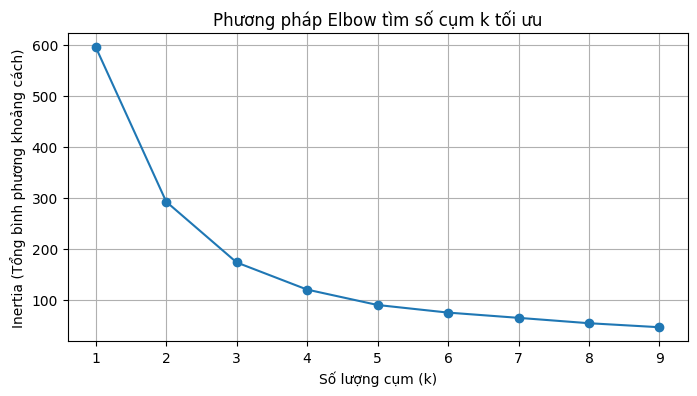

Nhìn vào biểu đồ, điểm gập (elbow) thường là k = 3 hoặc k = 4.


In [4]:
# --- 3. CHUẨN HÓA DỮ LIỆU & TÌM K TỐI ƯU ---

# Các đặc trưng dùng để gom nhóm
features_to_cluster = ["trips", "duration_avg", "distance_avg", "fare_avg"]

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(zone_features[features_to_cluster])

# Elbow method: thử k từ 1 đến 9
K_range = range(1, 10)
inertia = []

print("Đang chạy Elbow Method...")
for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

# Vẽ biểu đồ Elbow
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker="o")

plt.xlabel("Số lượng cụm (k)")
plt.ylabel("Inertia (Tổng bình phương khoảng cách)")
plt.title("Phương pháp Elbow tìm số cụm k tối ưu")
plt.grid(True)

plt.savefig(FIGURES / "advanced_pattern/elbow_method.png", bbox_inches="tight")
plt.show()

print("Nhìn vào biểu đồ, điểm gập (elbow) thường là k = 3 hoặc k = 4.")

In [5]:
# --- 4. ÁP DỤNG K-MEANS CLUSTERING ---

# Chọn k = 4 dựa trên phân tích Elbow
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Fit mô hình và gán nhãn cụm
zone_features["cluster"] = kmeans.fit_predict(X_scaled)

# Lưu kết quả
PROCESSED = Path("../../Data/processed")
zone_features.to_csv(
    PROCESSED / "advanced_pattern/zone_clusters_2021.csv",
    index=False
)

# Thống kê số lượng Zone trong mỗi cụm
print("Số lượng Zone trong mỗi cụm:")
print(zone_features["cluster"].value_counts().sort_index())

Số lượng Zone trong mỗi cụm:
cluster
0    86
1    30
2    31
3     2
Name: count, dtype: int64


In [6]:
from sklearn.metrics import silhouette_score

# Tính Silhouette Score cho k = 4
# Giá trị càng gần 1 thì phân cụm càng tốt
score = silhouette_score(X_scaled, zone_features["cluster"])

print(f"Silhouette Score cho k = 4 là: {score:.3f}")

Silhouette Score cho k = 4 là: 0.562



--- ĐẶC ĐIỂM TRUNG BÌNH CỦA TỪNG CỤM ---


,trips,duration_avg,distance_avg,fare_avg,revenue_total,count_zones
cluster,,,,,,
0,48957.19,17.79,4.22,17.46,913884.66,86
1,57257.53,34.22,11.61,41.78,2997867.21,30
2,713468.00,12.20,2.32,10.77,11792562.51,31
3,865.00,54.48,30.37,83.63,87101.43,2


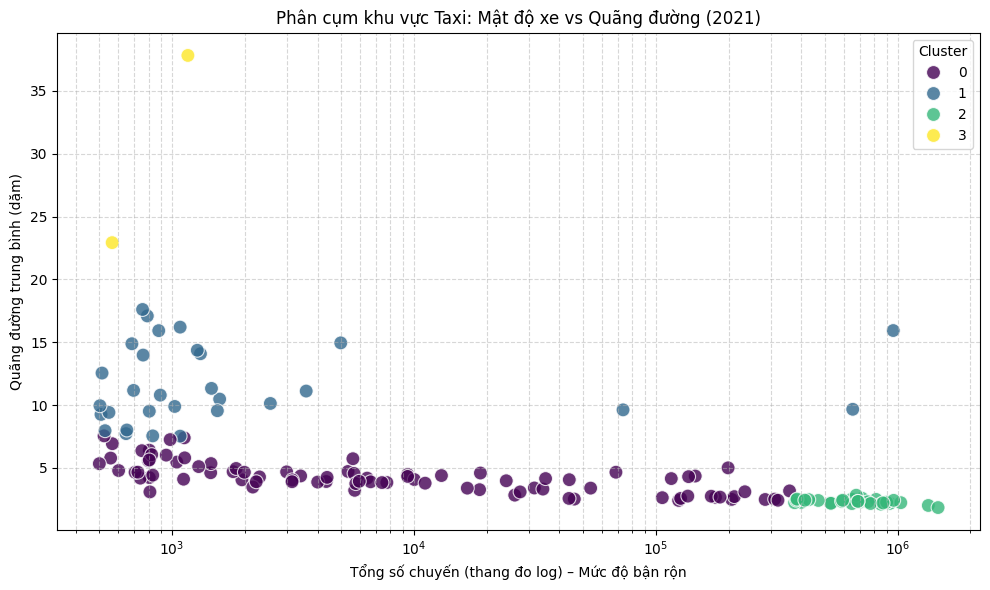

In [7]:
# --- 5. INTERPRETATION & VISUALIZATION ---

# Tổng hợp đặc trưng trung bình của từng cụm
cluster_summary = (
    zone_features
    .groupby("cluster")[features_to_cluster + ["revenue_total"]]
    .mean()
    .round(2)
)

cluster_summary["count_zones"] = zone_features["cluster"].value_counts()
print("\n--- ĐẶC ĐIỂM TRUNG BÌNH CỦA TỪNG CỤM ---")
display(cluster_summary)

# Scatter plot: Total Trips vs Average Distance
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=zone_features,
    x="trips",
    y="distance_avg",
    hue="cluster",
    palette="viridis",
    s=100,
    alpha=0.8
)

plt.xscale("log")
plt.title("Phân cụm khu vực Taxi: Mật độ xe vs Quãng đường (2021)")
plt.xlabel("Tổng số chuyến (thang đo log) – Mức độ bận rộn")
plt.ylabel("Quãng đường trung bình (dặm)")
plt.legend(title="Cluster")

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES / "advanced_pattern/cluster_scatter_plot.png", dpi=300)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_17312\3844008088.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_17312\3844008088.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_17312\3844008088.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


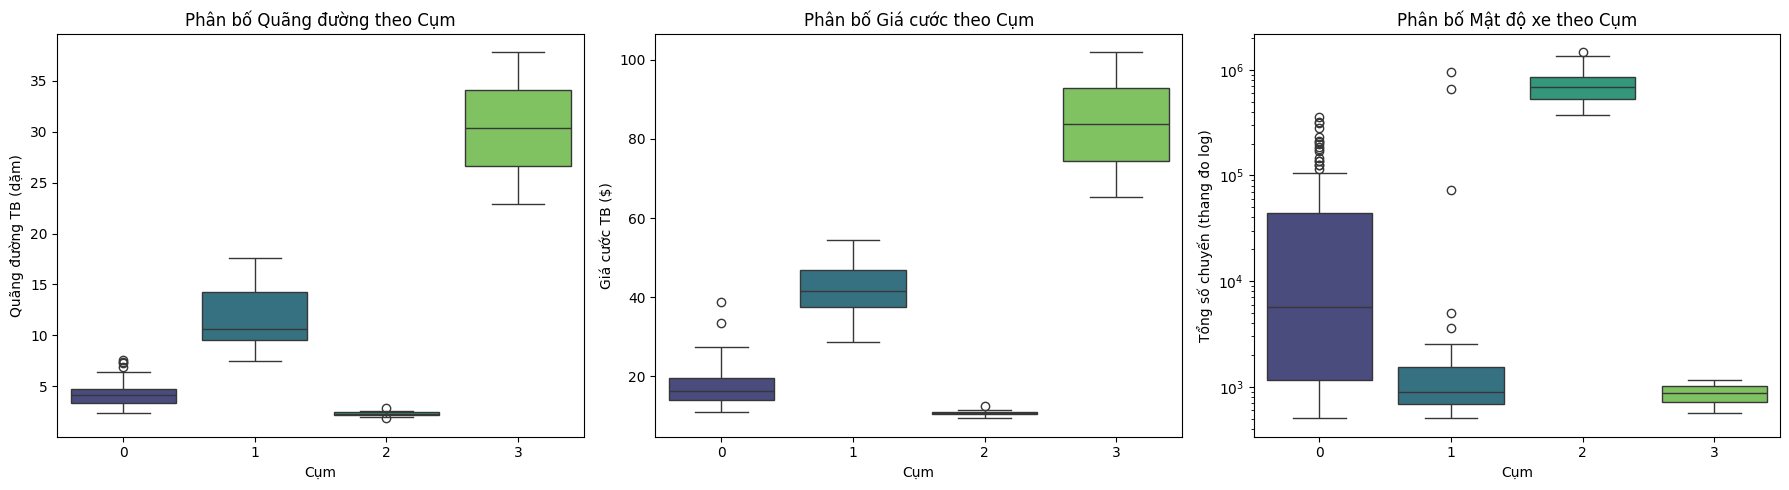

In [8]:
# --- 6. ADVANCED VISUALIZATION: BOXPLOTS ---
# Mục tiêu: So sánh phân bố các chỉ số giữa các cụm

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot 1: Quãng đường trung bình
sns.boxplot(
    data=zone_features,
    x="cluster",
    y="distance_avg",
    palette="viridis",
    ax=axes[0]
)
axes[0].set_title("Phân bố Quãng đường theo Cụm")
axes[0].set_xlabel("Cụm")
axes[0].set_ylabel("Quãng đường TB (dặm)")

# Boxplot 2: Giá cước trung bình
sns.boxplot(
    data=zone_features,
    x="cluster",
    y="fare_avg",
    palette="viridis",
    ax=axes[1]
)
axes[1].set_title("Phân bố Giá cước theo Cụm")
axes[1].set_xlabel("Cụm")
axes[1].set_ylabel("Giá cước TB ($)")

# Boxplot 3: Số lượng chuyến
sns.boxplot(
    data=zone_features,
    x="cluster",
    y="trips",
    palette="viridis",
    ax=axes[2]
)
axes[2].set_yscale("log")
axes[2].set_title("Phân bố Mật độ xe theo Cụm")
axes[2].set_xlabel("Cụm")
axes[2].set_ylabel("Tổng số chuyến (thang đo log)")

plt.tight_layout()
plt.savefig(FIGURES / "advanced_pattern/cluster_boxplots.png", dpi=300)
plt.show()

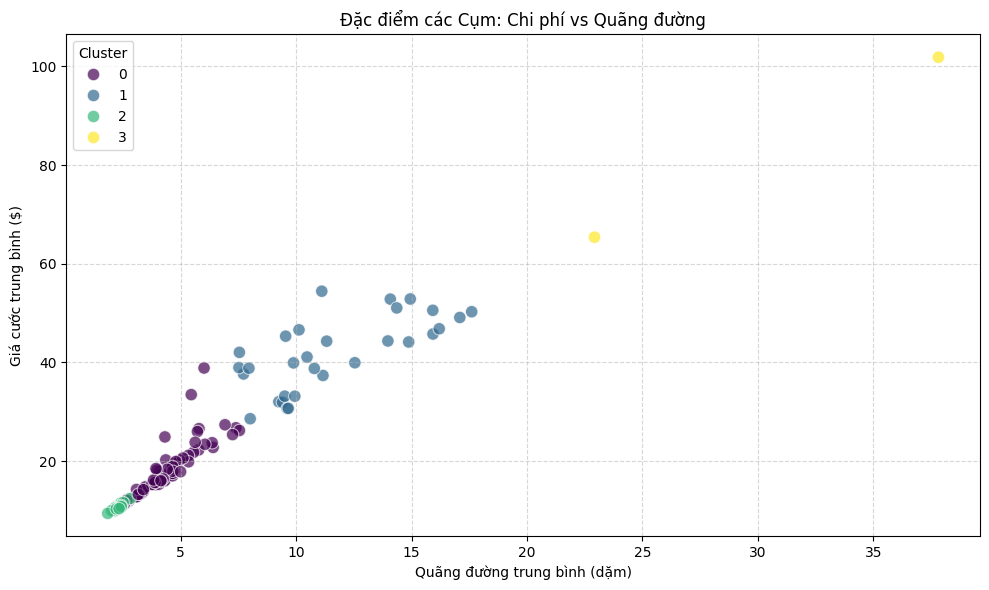

In [9]:
# --- 7. ECONOMIC VIEW: FARE VS DISTANCE ---

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=zone_features,
    x="distance_avg",
    y="fare_avg",
    hue="cluster",
    palette="viridis",
    s=80,
    alpha=0.7
)

plt.title("Đặc điểm các Cụm: Chi phí vs Quãng đường")
plt.xlabel("Quãng đường trung bình (dặm)")
plt.ylabel("Giá cước trung bình ($)")
plt.legend(title="Cluster")

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES / "advanced_pattern/fare_vs_distance.png", dpi=300)
plt.show()

📦 Đang nạp file bản đồ từ thư mục archive...


C:\Users\Admin\AppData\Local\Temp\ipykernel_17312\1331803182.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", 4)


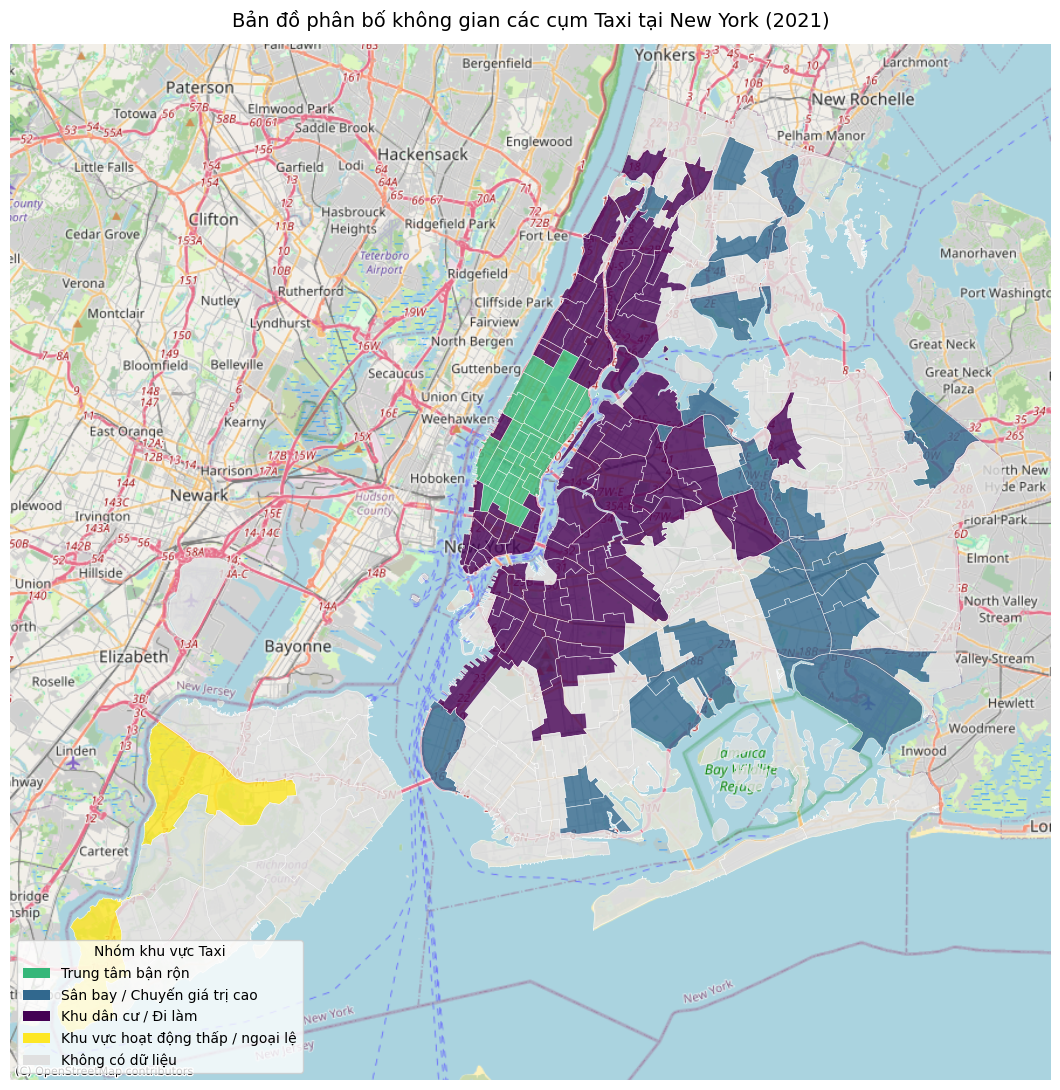

In [10]:
import geopandas as gpd
import contextily as ctx
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from pathlib import Path
import matplotlib.pyplot as plt

# -------- Paths: Trỏ thẳng vào thư mục archive nơi có đủ bộ file --------
ZONE_SHP = "../../Data/raw/archive/taxi_zones.shp"  # SỬA ĐOẠN NÀY
FIGURES = Path("../../Data/figures")

# -------- Load shapefile --------
print("📦 Đang nạp file bản đồ từ thư mục archive...")
zones_gdf = gpd.read_file(ZONE_SHP)
zones_gdf["LocationID"] = zones_gdf["LocationID"].astype(int)
zone_features["PULocationID"] = zone_features["PULocationID"].astype(int)

# --- CÁC PHẦN CODE TIẾP THEO GIỮ NGUYÊN HOÀN TOÀN ---

# -------- Merge cluster info --------
zones_cluster = zones_gdf.merge(
    zone_features[["PULocationID", "cluster"]],
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)

# -------- CRS for basemap --------
zones_cluster = zones_cluster.to_crs(epsg=3857)

# -------- Viridis color mapping (giống scatter plot) --------
cmap = cm.get_cmap("viridis", 4)
cluster_color_map = {
    0: mcolors.to_hex(cmap(0)),  # Commuters
    1: mcolors.to_hex(cmap(1)),  # Airports
    2: mcolors.to_hex(cmap(2)),  # Hubs
    3: mcolors.to_hex(cmap(3)),  # Low activity
}

zones_cluster["cluster_color"] = (
    zones_cluster["cluster"]
    .map(cluster_color_map)
    .fillna("#e0e0e0")
)

# -------- Legend (ĐÚNG THEO PHÂN TÍCH) --------
legend_elements = [
    Patch(facecolor=cluster_color_map[2], label="Trung tâm bận rộn"),
    Patch(facecolor=cluster_color_map[1], label="Sân bay / Chuyến giá trị cao"),
    Patch(facecolor=cluster_color_map[0], label="Khu dân cư / Đi làm"),
    Patch(facecolor=cluster_color_map[3], label="Khu vực hoạt động thấp / ngoại lệ"),
    Patch(facecolor="#e0e0e0", label="Không có dữ liệu"),
]

# -------- Plot --------
fig, ax = plt.subplots(1, 1, figsize=(11, 11))

zones_cluster.plot(
    color=zones_cluster["cluster_color"],
    linewidth=0.4,
    edgecolor="white",
    alpha=0.8,
    ax=ax
)

ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=11
)

ax.set_title(
    "Bản đồ phân bố không gian các cụm Taxi tại New York (2021)",
    fontsize=14,
    pad=12
)

ax.legend(
    handles=legend_elements,
    title="Nhóm khu vực Taxi",
    loc="lower left",
    frameon=True
)

ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURES / "advanced_pattern/map_phan_bo_cum_taxi_2021.png", dpi=300)
plt.show()